В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import probplot
from sklearn.linear_model import LinearRegression

medical_df = pd.read_csv('medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']


def normal_equations(X,y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

def rmse(targets, preditions):
  return np.sqrt(np.mean(np.square(targets - preditions)))

In [97]:
# дані для роботи nonsmoker age & nonsmoker charges:
# x:
non_smoker_X = non_smoker_df.age
# y:
non_smoker_Y = non_smoker_df.charges

# Додаємо колонку одиничок аби задачи bias терм (константу в моделі регресії)
non_smoker_X_with_intercept = np.c_[np.ones((non_smoker_X.shape[0], 1)), non_smoker_X]

# display('Незалежна змінна `age`:', non_smoker_X[:5], non_smoker_X_with_intercept[:5])

### Метод найменших квадратів

In [98]:
# 1. Метод найменших квадратів
print('1. Метод найменших квадратів:')

MNK_coefs = normal_equations(non_smoker_X_with_intercept, non_smoker_Y)
print('a. коефіцієнти моделі: ', MNK_coefs)

predictions_MNK = np.dot(non_smoker_X_with_intercept, MNK_coefs)
# display('Predictions vs Actiual vaslues:', predictions_MNK[:5], non_smoker_Y[:5])

non_smokers_mnk_rmse = rmse(non_smoker_Y, predictions_MNK)
non_smokers_mnk_mse_with_sklearn = mean_squared_error(non_smoker_Y, predictions_MNK, multioutput = 'uniform_average')
print('b. середньоквадратична помилка (rmse python only, rmse using sklearn): ', non_smokers_mnk_rmse, np.sqrt(non_smokers_mnk_mse_with_sklearn))
# print(non_smoker_Y.mean(), non_smoker_Y.std())
# non_smokers_r2 = r2_score(non_smoker_Y, predictions_MNK)
# print('R2: ', non_smokers_r2)

1. Метод найменших квадратів:
a. коефіцієнти моделі:  [-2091.42055657   267.24891283]
b. середньоквадратична помилка (rmse python only, rmse using sklearn):  4662.505766636395 4662.505766636395


### Метод граієнтного спуску

In [99]:
# Градієнтний спуск
def fbgd(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
        # print('m, b: ', m, b)
    return m, b, errors

In [100]:
non_smoker_X_with_intercept_2 = np.c_[non_smoker_X, np.ones((non_smoker_X.shape[0], 1))]
# non_smoker_X_with_intercept_2

In [101]:
def local_fbgd_iteration_with_errors(lr):
  m_res, b_res, errors_res = fbgd(non_smoker_X_with_intercept_2, non_smoker_Y, lr=lr, epochs=1000)
  predictions_result = m_res * non_smoker_X + b_res
  non_smokers_fbgd_rmse = rmse(non_smoker_Y, predictions_result)

  print()
  print(f'- при lr={lr}: ')
  print('Коефіцієнти: ', m_res, b_res)
  print('Помилка (rsme): ', non_smokers_fbgd_rmse)
  #display(predictions_result)

  plt.figure(figsize=(12,6))
  plt.subplot(1,2,1)
  plt.hist(errors_res)
  plt.subplot(1,2,2)
  probplot(errors_res, dist='norm', plot=plt);

  return predictions_result

In [102]:
# 2. Full-Batch градієнтного спуску з `numpy`
print('2. Full-Batch градієнтного спуску з `numpy`:')

2. Full-Batch градієнтного спуску з `numpy`:



- при lr=1e-05: 
Коефіцієнти:  220.15455551129122 0.2130065279986346
Помилка (rsme):  4715.349750127827


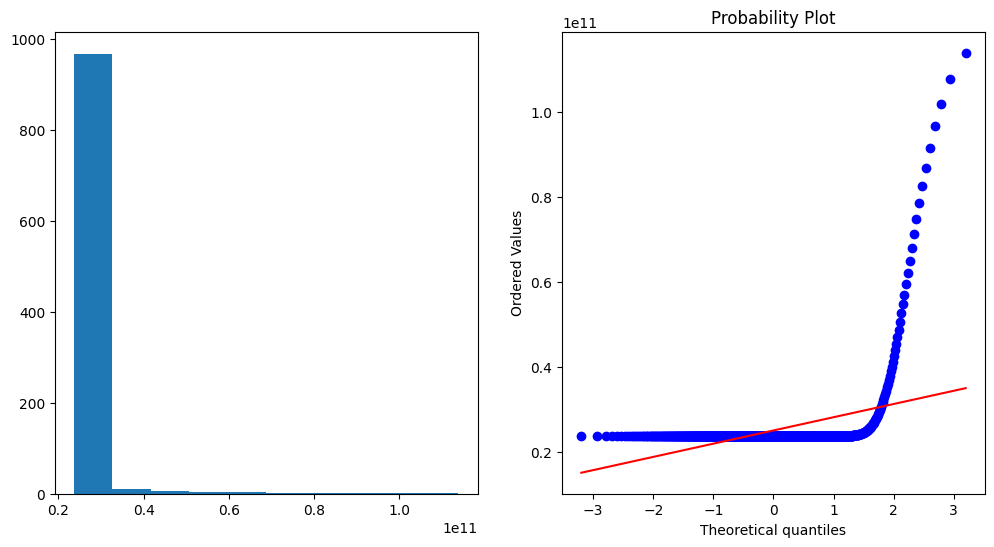

In [103]:
lr_param = 0.00001
predictions_fbgd = local_fbgd_iteration_with_errors(lr_param)


- при lr=1e-06: 
Коефіцієнти:  213.45756906581036 4.331249162394349
Помилка (rsme):  4723.647721473958


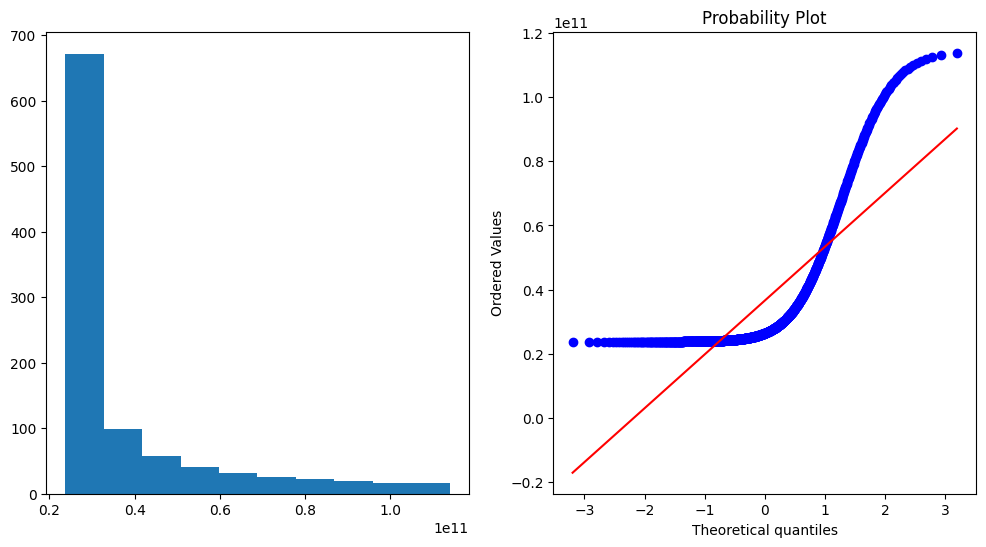

In [104]:
lr_param = 0.000001
predictions_fbgd = local_fbgd_iteration_with_errors(lr_param)


- при lr=0.0001: 
Коефіцієнти:  221.1045843794301 -41.98126853149977
Помилка (rsme):  4713.250582815521


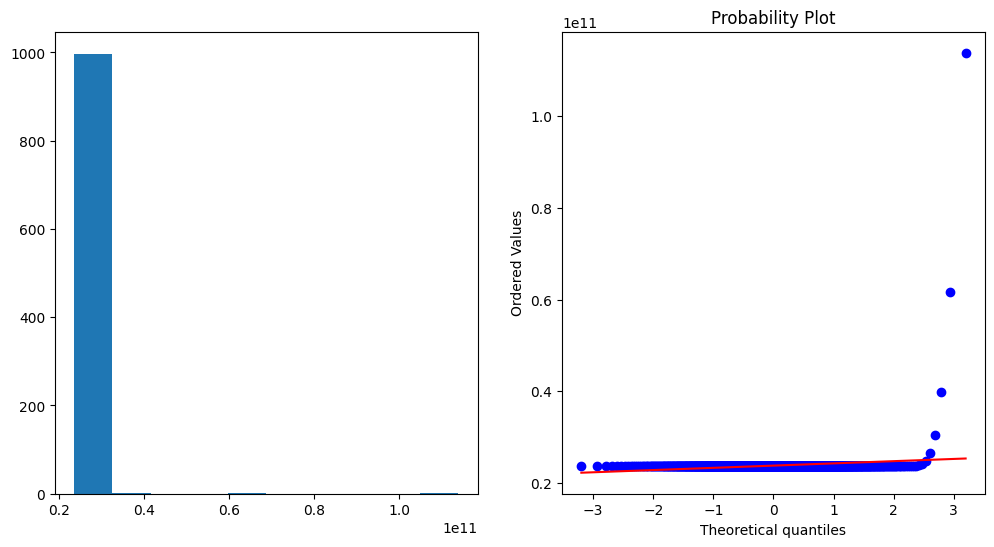

In [105]:
lr_param = 0.0001
predictions_fbgd = local_fbgd_iteration_with_errors(lr_param)

### 3. Використовуючи scikit-learn.LinearRegression

In [106]:
# 3. Модель лінійної регресії засобами Scikit-learn (МНК)
print('3. Модель лінійної регресії засобами Scikit-learn (МНК):')

non_smoker_X_as_frame = non_smoker_X.to_frame();

lin_reg = LinearRegression()
lin_reg.fit(non_smoker_X_as_frame, non_smoker_Y)

print('a. коефіцієнти моделі: ', lin_reg.intercept_, lin_reg.coef_)

predictions_sklearn = lin_reg.predict(non_smoker_X_as_frame)

lin_reg_rmse = mean_squared_error(non_smoker_Y, predictions_sklearn, multioutput = 'uniform_average')
print('b. середньоквадратична помилка (rmse): ', np.sqrt(lin_reg_rmse))

3. Модель лінійної регресії засобами Scikit-learn (МНК):
a. коефіцієнти моделі:  -2091.4205565650864 [267.24891283]
b. середньоквадратична помилка (rmse):  4662.505766636395


### Візуалізація регресій

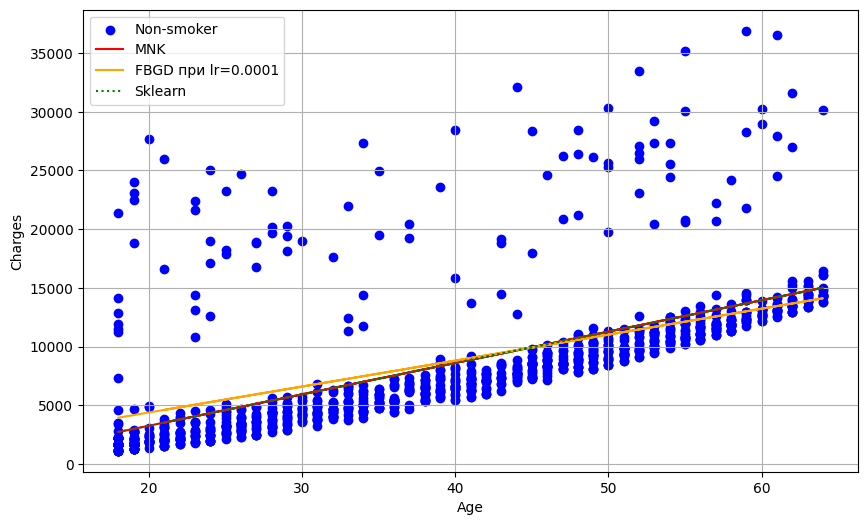

In [107]:
# Візуалізація результатів
plt.figure(figsize=(10, 6))
plt.scatter(non_smoker_X, non_smoker_Y, color='blue', label='Non-smoker')
plt.plot(non_smoker_X, predictions_MNK, color='red', label='MNK')
plt.plot(non_smoker_X, predictions_fbgd, color='orange', label='FBGD при lr=0.0001')
plt.plot(non_smoker_X, predictions_sklearn, color='green', linestyle='dotted', label='Sklearn') # побачимо, що MNK і sklearn співпадають
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.grid(True)
plt.show()

### Спостереження

1. MNK і sklearn співпадають
2. FBGD трошки відрізняється, можливо треба більше погратись з learning rate (хоча модель все одно близка до інших двох).
3. Я подививлась в своє домашнє HW 2.1. Аналіз ознак для побудови лінійної регресії - https://colab.research.google.com/drive/1H5gzdlbjaVRT-7T9tulFCqDuGdj1nV66#scrollTo=bgdqJ-QSzKUz. Там моє припущення було

try_parameters(non_smoker_df, 290, -4500)

MNK дав коефіцієнти:

 267.24891283 -2091.4205565650864

Досить близко вгадала, принаймні з одним коефіцієнтом, то взагалі непогано.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

a. коефіцієнти моделі:  20294.128126915966 [305.23760211]
b. середньоквадратична помилка (rmse):  10711.00334810241


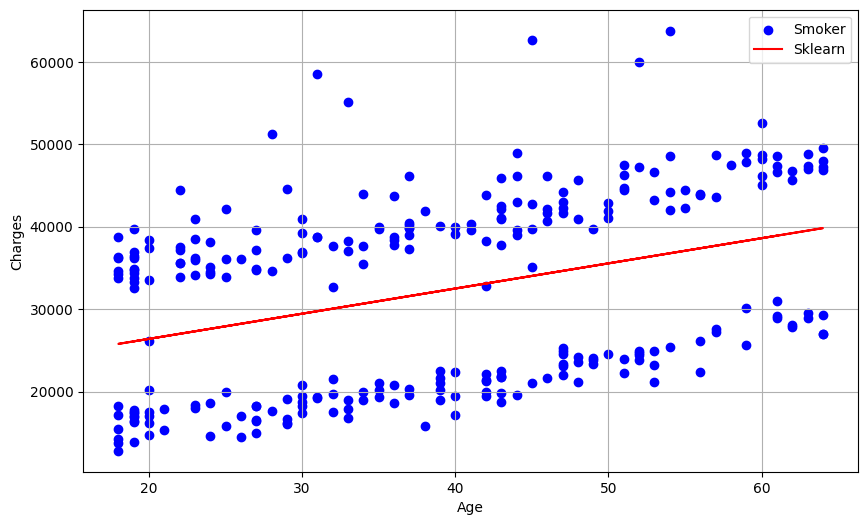

In [108]:
smoker_df = medical_df[medical_df.smoker == 'yes']

# x:
smoker_X = smoker_df.age
# y:
smoker_Y = smoker_df.charges

smoker_X_as_frame = smoker_X.to_frame();

lin_reg = LinearRegression()
lin_reg.fit(smoker_X_as_frame, smoker_Y)

print('a. коефіцієнти моделі: ', lin_reg.intercept_, lin_reg.coef_)

predictions_sklearn = lin_reg.predict(smoker_X_as_frame)

lin_reg_rmse = mean_squared_error(smoker_Y, predictions_sklearn, multioutput = 'uniform_average')
print('b. середньоквадратична помилка (rmse): ', np.sqrt(lin_reg_rmse))


# Візуалізація результатів
plt.figure(figsize=(10, 6))
plt.scatter(smoker_X, smoker_Y, color='blue', label='Smoker')
plt.plot(smoker_X, predictions_sklearn, color='red', label='Sklearn')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.grid(True)
plt.show()

In [109]:
r2_value = r2_score(smoker_Y, predictions_sklearn)
r2_value

0.13558924096084068

In [110]:
smoker_Y.describe()

,charges
count,274.000000
mean,32050.231832
std,11541.547176
min,12829.455100
25%,20826.244213
50%,34456.348450
75%,41019.207275
max,63770.428010


### Спостереження

Я вважаю, що ця модель не дуже хороша. Наша модель дає помилку 10711, практично таку саму як стандартне відхилення 11541. Це означає, що передбачення будуть такі самі, ніби модель випадковим чином вгадує. Для підтвердження я ще знайшла r2 метрику, і вона дорівнює 0.136 - це поганий показник. У нас є два очевидні кластери даних. І цілком можливо, що є ще якісь взаємозі"язки, які варто дослідити.